# Notebook 3 — Feature Analysis, Importance & Selection

This notebook performs a comprehensive analysis of all available features in the cleaned traffic dataset. The goal is to identify the most relevant predictors of hourly traffic volume (`vehicle_count`) through correlation analysis, statistical testing, model-based importance extraction, and multicollinearity checks. The findings from this notebook directly inform the feature selection decisions used in the baseline model training notebook.

## 1. Feature Overview

We begin by loading the cleaned dataset and classifying all columns into the following categories:

- **Numerical features** — raw sensor measurements including speed, length, headway and gap statistics
- **Temporal features** — time-based columns including year, month, day and hour
- **Identifier features** — sensor site and lane identifiers (cosit, lane)
- **Engineered categorical features** — derived during preprocessing from numerical columns
- **Encoded features** — numerical indices of categorical features for ML compatibility
- **Excluded features** — individual vehicle counts excluded from ML due to data leakage
- **Target** — `vehicle_count`, the hourly total vehicle count to be predicted

In [0]:
df = spark.table("traffic_count_cleaned_data")

numerical_features = [
    "avg_speed", "max_speed", "min_speed", "speed_std",
    "avg_length", "max_length", "length_std",
    "avg_headway", "max_headway", "min_headway", "headway_std",
    "avg_gap", "max_gap", "min_gap", "gap_std"
]

temporal_features = [
    "year", "month", "day", "hour"
]

identifier_features = [
    "cosit", "lane"
]

engineered_features = [
    "time_of_day", "day_type", "traffic_level",
    "speed_category", "congestion_index"
]

encoded_features = [
    "time_of_day_index", "day_type_index", "traffic_level_index",
    "speed_category_index", "congestion_index_index"
]

vehicle_count_features = [
    "CAR_count", "HGV_ART_count", "BUS_count", "HGV_RIG_count",
    "CARAVAN_count", "LGV_count", "MBIKE_count"
]

target = "vehicle_count"

categories = {
    "Numerical"              : numerical_features,
    "Temporal"               : temporal_features,
    "Identifier"             : identifier_features,
    "Engineered Categorical" : engineered_features,
    "Encoded Categorical"    : encoded_features,
    "Vehicle Count Columns"  : vehicle_count_features,
    "Target"                 : [target]
}

print(f"{'Category':<25} {'Count':>5}   Columns")
print("-" * 100)
for category, cols in categories.items():
    print(f"{category:<25} {len(cols):>5}   {cols}")
print("-" * 100)
print(f"{'Total Dataset Columns':<25} {len(df.columns):>5}")

Category                  Count   Columns
----------------------------------------------------------------------------------------------------
Numerical                    15   ['avg_speed', 'max_speed', 'min_speed', 'speed_std', 'avg_length', 'max_length', 'length_std', 'avg_headway', 'max_headway', 'min_headway', 'headway_std', 'avg_gap', 'max_gap', 'min_gap', 'gap_std']
Temporal                      4   ['year', 'month', 'day', 'hour']
Identifier                    2   ['cosit', 'lane']
Engineered Categorical        5   ['time_of_day', 'day_type', 'traffic_level', 'speed_category', 'congestion_index']
Encoded Categorical           5   ['time_of_day_index', 'day_type_index', 'traffic_level_index', 'speed_category_index', 'congestion_index_index']
Vehicle Count Columns         7   ['CAR_count', 'HGV_ART_count', 'BUS_count', 'HGV_RIG_count', 'CARAVAN_count', 'LGV_count', 'MBIKE_count']
Target                        1   ['vehicle_count']
-------------------------------------------------

In [0]:
pre_available_features = [
    "month", "day", "hour",      
    "cosit", "lane",               
    "day_type_index"               
]

concurrent_features = [
    "avg_speed", "max_speed", "min_speed", "speed_std",
    "avg_length", "max_length", "length_std",
    "avg_headway", "min_headway",
    "avg_gap", "min_gap",
    "speed_category_index", "congestion_index_index"
]

print(f"Pre-available features  : {len(pre_available_features)}")
print(f"Concurrent features     : {len(concurrent_features)}")
print(f"Total ML features       : {len(pre_available_features + concurrent_features)}")

Pre-available features  : 6
Concurrent features     : 13
Total ML features       : 19


## 2. Correlation Analysis

Correlation analysis measures the linear relationship between each feature and the target variable `vehicle_count`. We perform two levels of analysis — feature vs target to identify strong predictors, and feature vs feature to detect multicollinearity between features.

### 2.1 Feature vs Target Correlation

In [0]:
from pyspark.sql.functions import corr

all_features = (
    numerical_features +
    temporal_features +
    identifier_features +
    encoded_features +
    vehicle_count_features
)

print(f"{'Feature':<35} {'Correlation':>12}")
print("-" * 50)
for feat in all_features:
    corr_val = df.select(corr(feat, target)).first()[0]
    corr_str = str(round(corr_val, 4)) if corr_val is not None else "N/A (zero variance)"
    print(f"{feat:<35} {corr_str:>12}")

Feature                              Correlation
--------------------------------------------------
avg_speed                                -0.1446
max_speed                                 0.0936
min_speed                                -0.4309
speed_std                                -0.1746
avg_length                               -0.1189
max_length                                0.4046
length_std                               -0.0389
avg_headway                              -0.4161
max_headway                              -0.5051
min_headway                               0.1549
headway_std                              -0.4402
avg_gap                                  -0.4168
max_gap                                  -0.5079
min_gap                                  -0.0145
gap_std                                  -0.4402
year                                N/A (zero variance)
month                                     0.0081
day                                       0.0097
hour       

### 2.2 Feature vs Target Correlation — Visualised

The correlation values are visualised as a ranked bar chart. Features shown in red indicate data leakage — they are either directly derived from or constitute the target variable `vehicle_count` and will be excluded from model training.

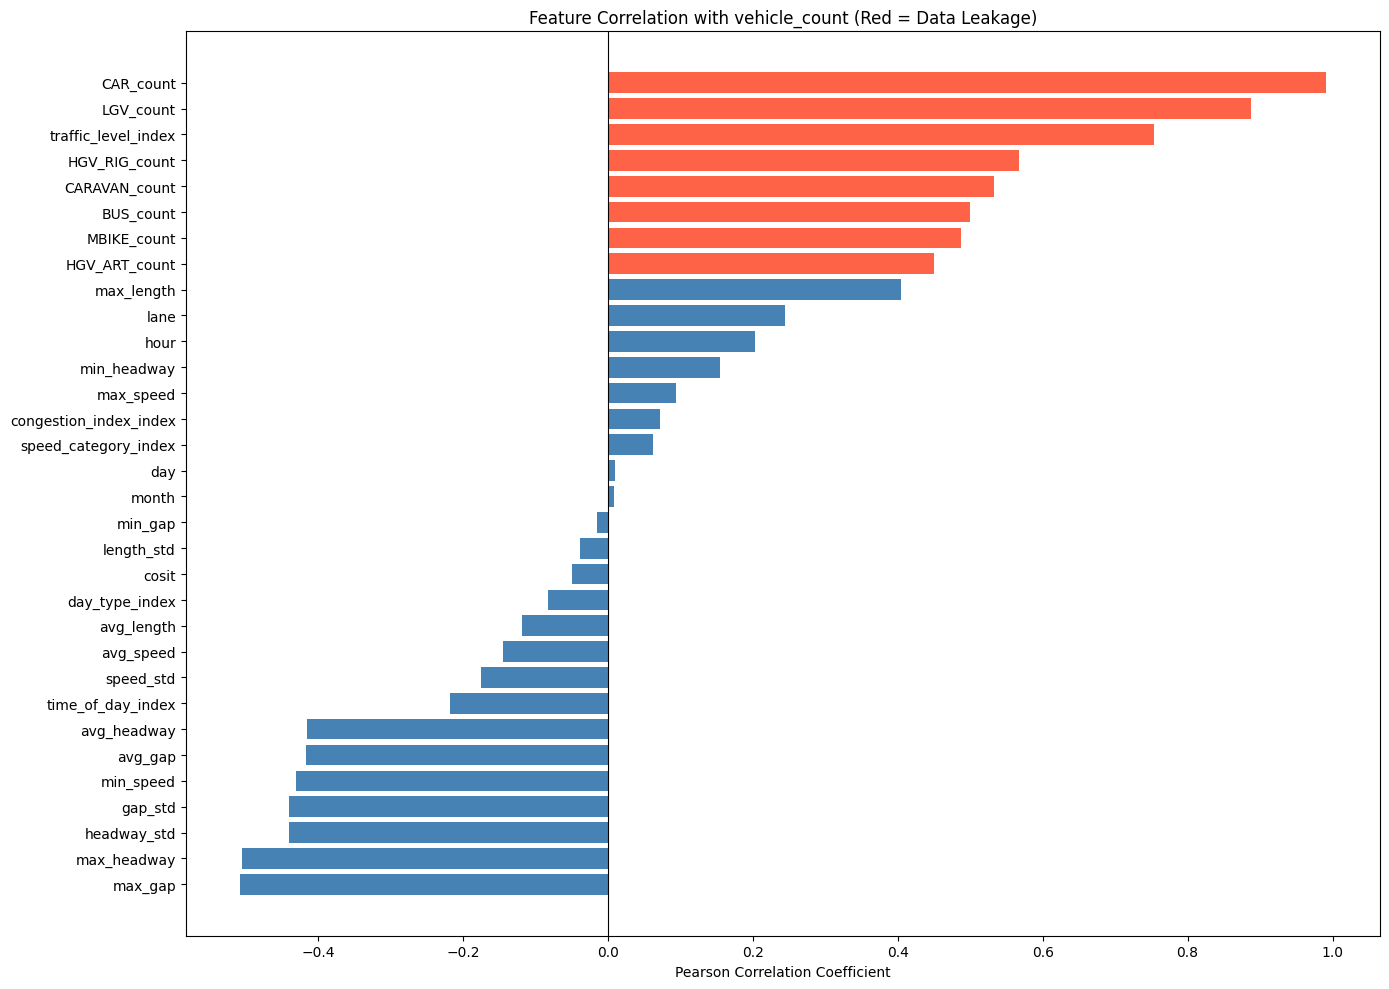

In [0]:
import matplotlib.pyplot as plt

leakage_features = vehicle_count_features + ["traffic_level_index", "traffic_level"]

corr_dict = {}
for feat in all_features:
    corr_val = df.select(corr(feat, target)).first()[0]
    if corr_val is not None:
        corr_dict[feat] = round(corr_val, 4)

corr_sorted = dict(sorted(corr_dict.items(), key=lambda x: x[1]))

colors = ["tomato" if f in leakage_features else "steelblue" for f in corr_sorted.keys()]

plt.figure(figsize=(14, 10))
plt.barh(list(corr_sorted.keys()), list(corr_sorted.values()), color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Feature Correlation with vehicle_count (Red = Data Leakage)")
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()

### 2.3 Data Leakage Identification

The correlation analysis reveals two groups of features that constitute data leakage and must be excluded from model training:

**Group 1 — Individual Vehicle Count Columns:**
`CAR_count` (0.99), `LGV_count` (0.89), `HGV_RIG_count` (0.57), `CARAVAN_count` (0.53), `BUS_count` (0.50), `MBIKE_count` (0.49), `HGV_ART_count` (0.45) — these columns directly sum to `vehicle_count` and would cause the model to trivially learn the target.

**Group 2 — Derived Categorical Feature:**
`traffic_level_index` (0.75) and `traffic_level` were binned directly from `vehicle_count` during feature engineering — including them would leak the target into the feature space.

Additionally, `year` is dropped due to zero variance — the entire dataset covers 2019 only, providing no predictive signal.

These features are removed from the ML feature set going forward.

In [0]:
leakage_features = vehicle_count_features + ["traffic_level_index", "traffic_level", "year"]

ml_features = [
    f for f in (
        numerical_features +
        temporal_features +
        identifier_features +
        encoded_features
    )
    if f not in leakage_features
]

print("Final ML feature set:")
for i, f in enumerate(ml_features):
    print(f"  {i+1:>3}. {f}")

print(f"\nTotal ML features : {len(ml_features)}")

Final ML feature set:
    1. avg_speed
    2. max_speed
    3. min_speed
    4. speed_std
    5. avg_length
    6. max_length
    7. length_std
    8. avg_headway
    9. max_headway
   10. min_headway
   11. headway_std
   12. avg_gap
   13. max_gap
   14. min_gap
   15. gap_std
   16. month
   17. day
   18. hour
   19. cosit
   20. lane
   21. time_of_day_index
   22. day_type_index
   23. speed_category_index
   24. congestion_index_index

Total ML features : 24


### 2.4 Feature vs Feature Correlation Heatmap

We examine the correlation between all ML features to identify multicollinear pairs — features that are highly correlated with each other carry redundant information and can negatively impact model performance.

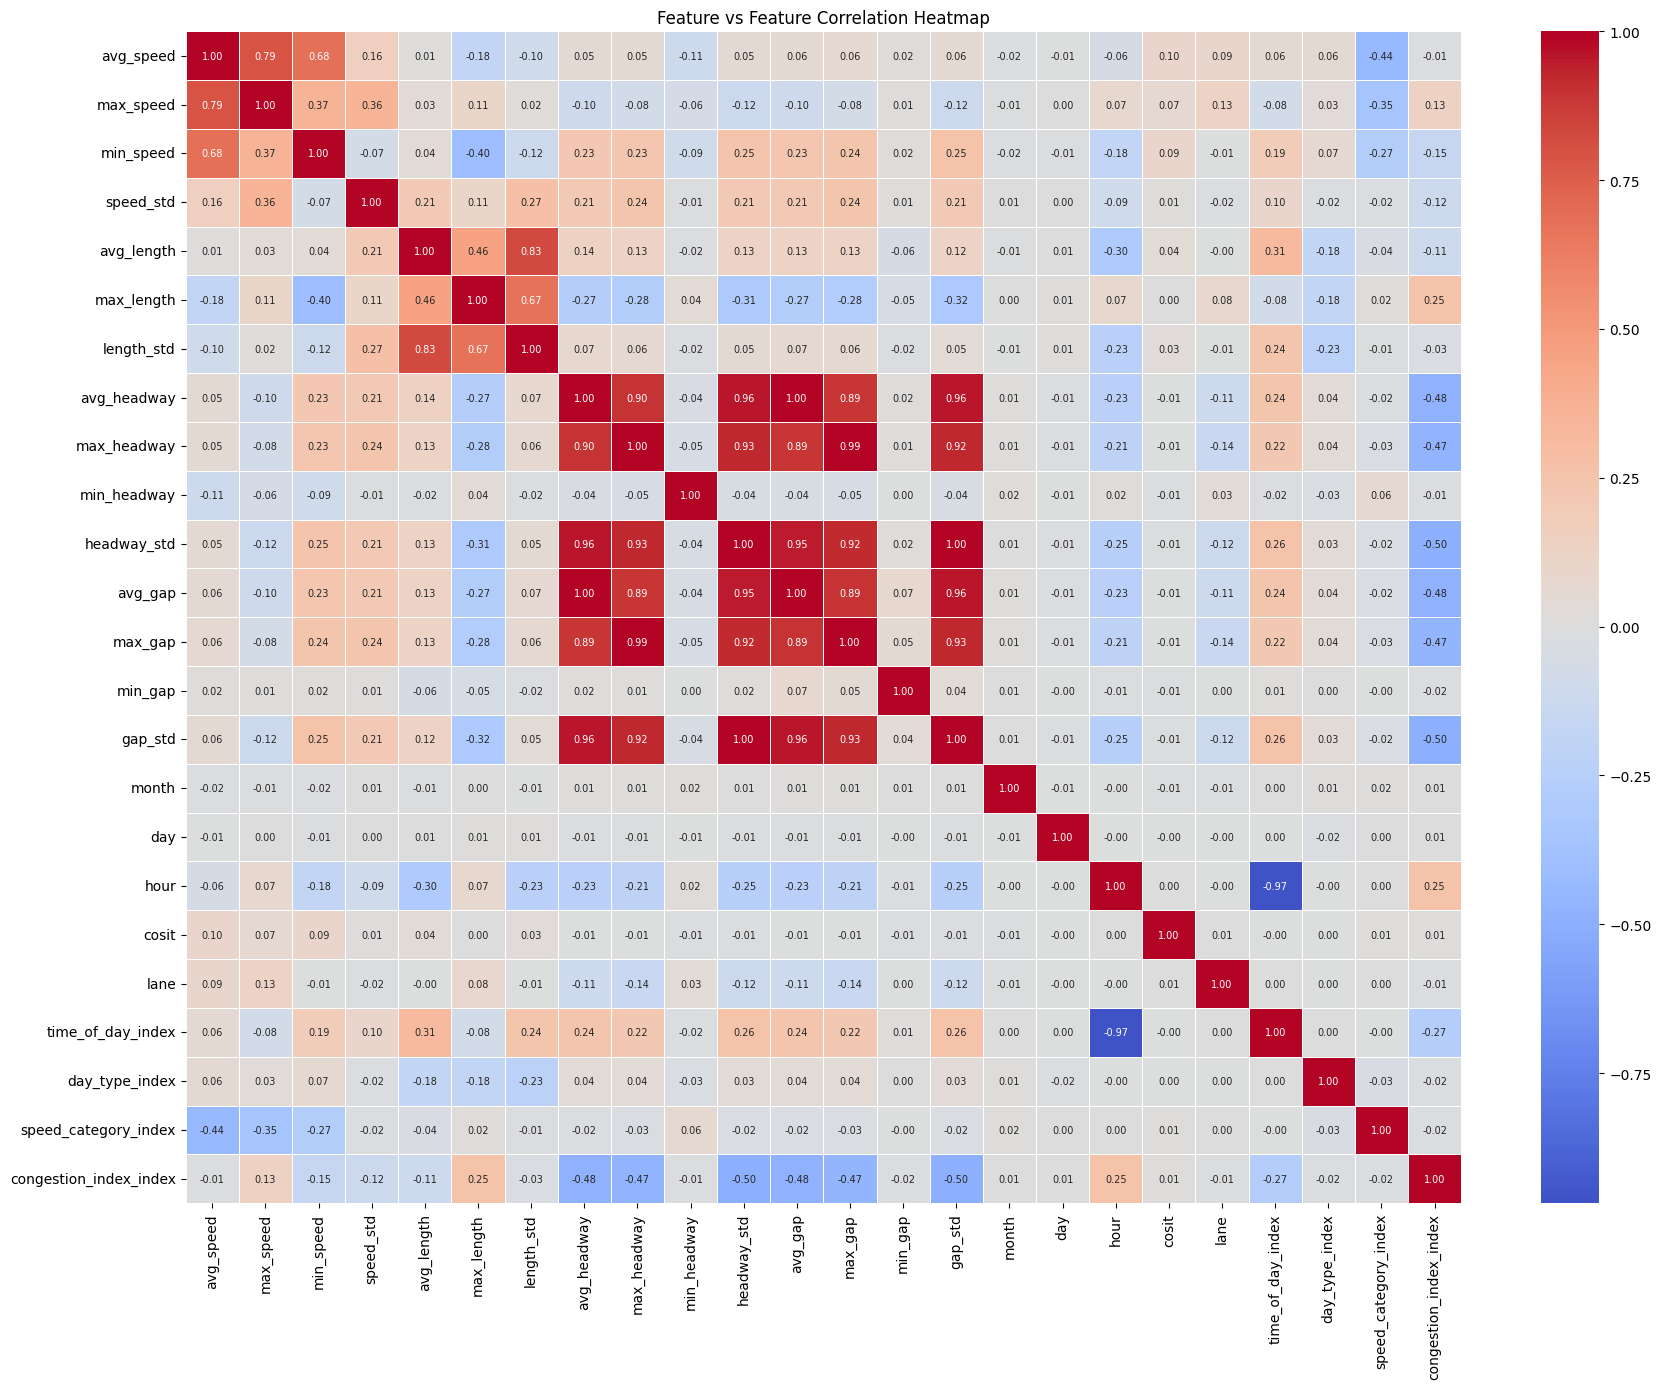

In [0]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

assembler = VectorAssembler(inputCols=ml_features, outputCol="corr_features")
df_vector = assembler.transform(df).select("corr_features")

corr_matrix = Correlation.corr(df_vector, "corr_features").head()[0].toArray()

corr_pdf = pd.DataFrame(corr_matrix, index=ml_features, columns=ml_features)

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_pdf,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Feature vs Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [0]:
threshold = 0.8

print("Highly correlated feature pairs (|correlation| > 0.8):")
print("-" * 60)
for i in range(len(ml_features)):
    for j in range(i+1, len(ml_features)):
        val = corr_pdf.iloc[i, j]
        if abs(val) > threshold:
            print(f"{ml_features[i]:<25} vs {ml_features[j]:<25} : {round(val, 4)}")

Highly correlated feature pairs (|correlation| > 0.8):
------------------------------------------------------------
avg_length                vs length_std                : 0.8272
avg_headway               vs max_headway               : 0.8957
avg_headway               vs headway_std               : 0.9574
avg_headway               vs avg_gap                   : 0.9952
avg_headway               vs max_gap                   : 0.8919
avg_headway               vs gap_std                   : 0.9552
max_headway               vs headway_std               : 0.9263
max_headway               vs avg_gap                   : 0.8922
max_headway               vs max_gap                   : 0.9949
max_headway               vs gap_std                   : 0.9243
headway_std               vs avg_gap                   : 0.9538
headway_std               vs max_gap                   : 0.9224
headway_std               vs gap_std                   : 0.9979
avg_gap                   vs max_gap                

### 2.5 Multicollinearity Analysis & Feature Removal

The correlation analysis identified three groups of highly correlated features:

**Headway & Gap Cluster** — `avg_headway`, `max_headway`, `headway_std`, `avg_gap`, `max_gap` and `gap_std` are all correlated above 0.89 with each other, as they all measure the time and space between vehicles. We retain one representative from each group — `avg_headway` and `avg_gap` — and drop the remaining four.

**Hour vs Time of Day** — `hour` and `time_of_day_index` exhibit a correlation of -0.97 as `time_of_day_index` was directly derived from `hour` during feature engineering. We retain `hour` as it carries more granular information across 24 values versus 4 categories.

`length_std` is retained alongside `avg_length` as the correlation of 0.83, while notable, is not extreme enough to warrant removal — the standard deviation carries additional variability information not captured by the mean alone.

In [0]:
drop_features = ["max_headway", "headway_std", "max_gap", "gap_std", "time_of_day_index"]

ml_features = [f for f in ml_features if f not in drop_features]

print("Updated ML feature set after multicollinearity removal:")
for i, f in enumerate(ml_features):
    print(f"  {i+1:>3}. {f}")

print(f"\nTotal ML features : {len(ml_features)}")

Updated ML feature set after multicollinearity removal:
    1. avg_speed
    2. max_speed
    3. min_speed
    4. speed_std
    5. avg_length
    6. max_length
    7. length_std
    8. avg_headway
    9. min_headway
   10. avg_gap
   11. min_gap
   12. month
   13. day
   14. hour
   15. cosit
   16. lane
   17. day_type_index
   18. speed_category_index
   19. congestion_index_index

Total ML features : 19


## 3. Statistical Feature Analysis

We perform two statistical analyses to further validate our feature selection:

- **ANOVA Test** — examines whether mean `vehicle_count` differs significantly across the categories of each engineered categorical feature. A large difference in group means indicates the feature carries strong predictive signal.
- **Variance Analysis** — identifies features with near-zero variance that contribute no discriminative information to the model.

### 3.1 ANOVA — Mean vehicle_count Across Categorical Groups

For each engineered categorical feature, we compute the mean and standard deviation of `vehicle_count` per category and visualise the differences. Features where group means differ substantially are considered statistically informative.

In [0]:
from pyspark.sql.functions import avg, stddev, count
import matplotlib.pyplot as plt

categorical_to_test = [
    "time_of_day", "day_type", "speed_category", "congestion_index"
]

anova_results = {}

for cat_col in categorical_to_test:
    result = df.groupBy(cat_col).agg(
        avg("vehicle_count").alias("mean"),
        stddev("vehicle_count").alias("std"),
        count("vehicle_count").alias("count")
    ).orderBy("mean", ascending=False).toPandas()
    anova_results[cat_col] = result
    print(f"\n{cat_col}")
    print("-" * 50)
    print(result.to_string(index=False))


time_of_day
--------------------------------------------------
time_of_day       mean        std   count
  Afternoon 497.304805 397.225585 1900756
    Morning 377.177601 377.440962 1895483
    Evening 245.601245 270.006332 1903593
      Night  49.222351  77.689909 1804081

day_type
--------------------------------------------------
day_type       mean        std   count
 Weekday 313.953716 367.826486 5335991
 Weekend 249.667902 300.314779 2167922

speed_category
--------------------------------------------------
speed_category       mean        std   count
          Slow 340.935483 401.164962 1875221
          Fast 315.379893 359.738482 1875359
      Moderate 308.310522 360.588891 1877616
     Very Fast 216.901629 251.571613 1875717

congestion_index
--------------------------------------------------
congestion_index       mean        std   count
       Congested 729.265188 433.834656 1876892
            Mild 309.793202  94.720089 1874119
       Free Flow 113.186693  46.988361 1875753

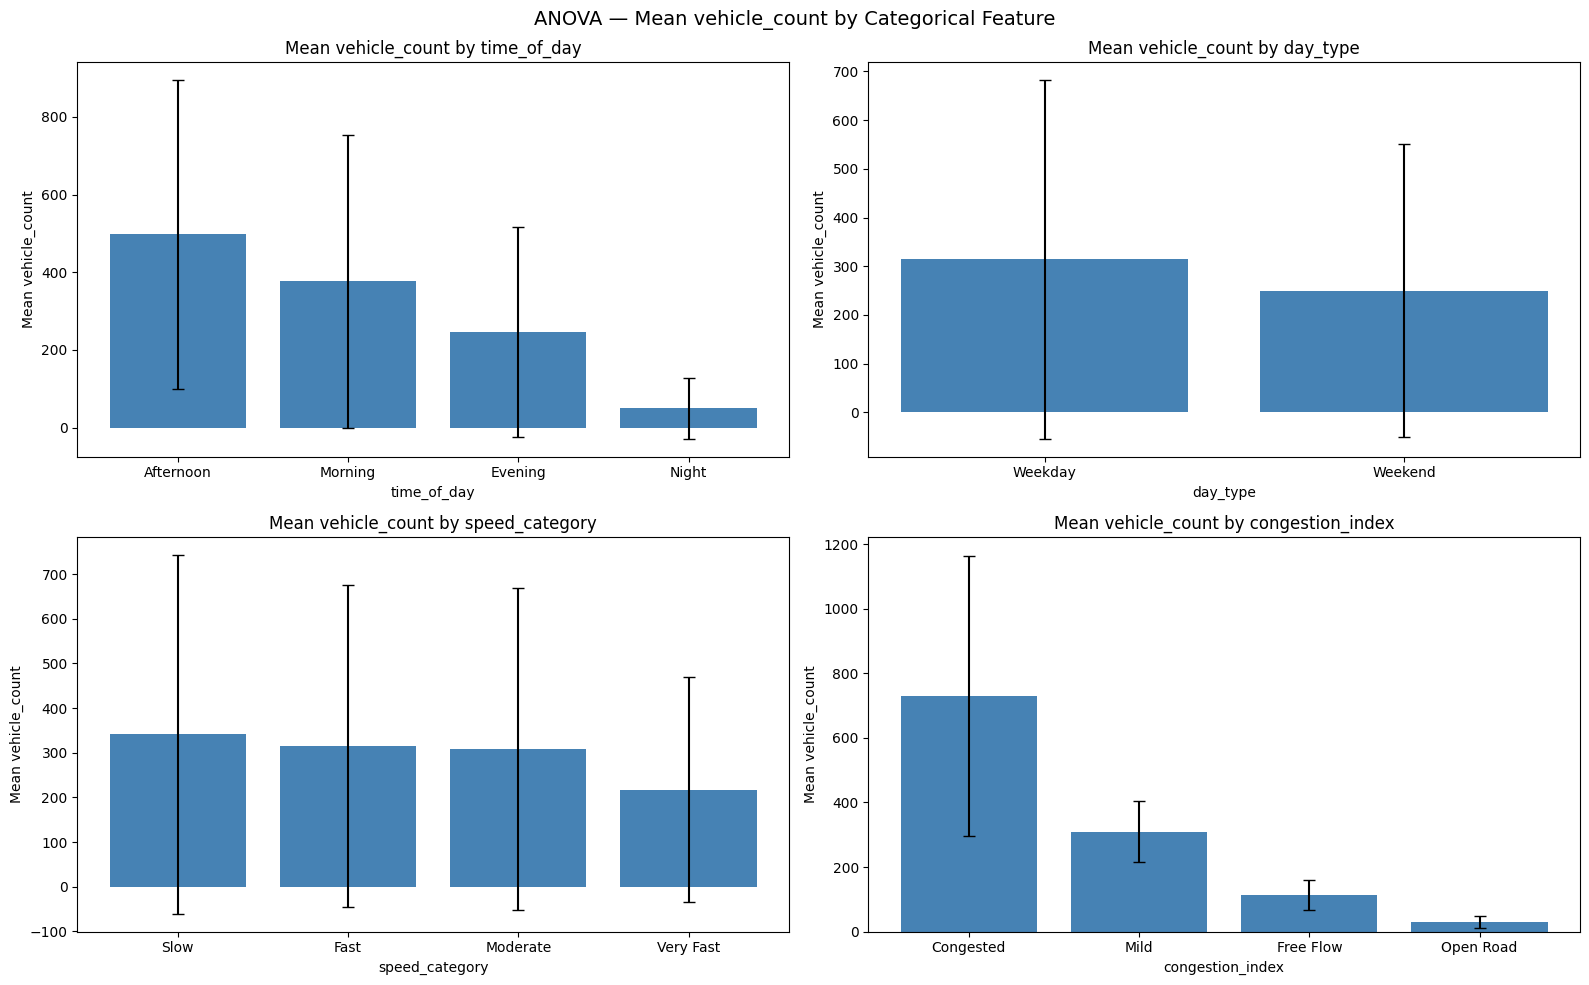

In [0]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, cat_col in enumerate(categorical_to_test):
    result = anova_results[cat_col]
    axes[i].bar(result[cat_col], result["mean"], yerr=result["std"],
                color="steelblue", edgecolor="none", capsize=4)
    axes[i].set_title(f"Mean vehicle_count by {cat_col}")
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel("Mean vehicle_count")

plt.suptitle("ANOVA — Mean vehicle_count by Categorical Feature", fontsize=14)
plt.tight_layout()
plt.show()

### 3.1 ANOVA Findings

The group mean analysis reveals clear and meaningful differences in `vehicle_count` across all four categorical features, confirming their predictive value:

**Time of Day** — Afternoon records the highest mean vehicle count (497), followed by Morning (377) and Evening (246), with Night being significantly quieter (49). This reflects the expected daily traffic rhythm on Irish roads, with peak activity during daytime hours.

**Day Type** — Weekdays show a higher mean vehicle count (314) compared to Weekends (250), consistent with commuter-driven traffic patterns during working days.

**Speed Category** — Mean vehicle count decreases as speed increases — Slow (341), Fast (315), Moderate (308), and Very Fast (217). This inverse relationship suggests that higher speeds are associated with lighter, more free-flowing traffic conditions.

**Congestion Index** — The most striking pattern emerges here, with Congested hours recording a mean of 729 vehicles, dropping sharply through Mild (310), Free Flow (113), and Open Road (29). This strong monotonic relationship confirms that the congestion index is a highly informative engineered feature.

All four categorical features exhibit substantial between-group variation, confirming their relevance as predictors of hourly traffic volume.

### 3.2 Variance Analysis

Features with near-zero variance contribute no discriminative information to the model. Variance is plotted on a log scale due to the wide range of values across features.

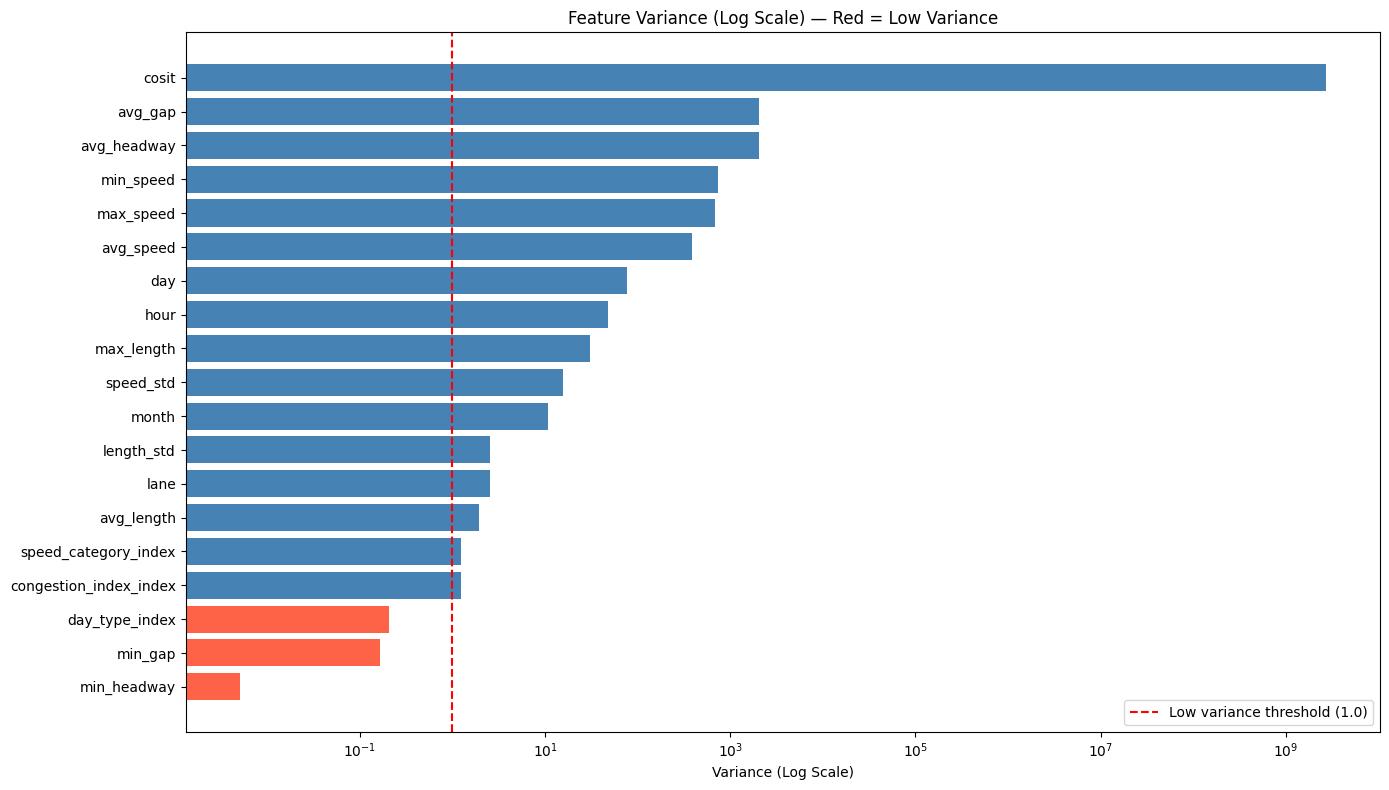

In [0]:
from pyspark.sql.functions import variance
import matplotlib.pyplot as plt
import numpy as np

variance_dict = {}
for feat in ml_features:
    var_val = df.select(variance(feat)).first()[0]
    if var_val is not None:
        variance_dict[feat] = var_val

variance_sorted = dict(sorted(variance_dict.items(), key=lambda x: x[1]))

colors = ["tomato" if v < 1.0 else "steelblue" for v in variance_sorted.values()]

plt.figure(figsize=(14, 8))
plt.barh(list(variance_sorted.keys()), list(variance_sorted.values()), color=colors)
plt.xscale("log")
plt.axvline(x=1.0, color="red", linestyle="--", linewidth=1.5, label="Low variance threshold (1.0)")
plt.title("Feature Variance (Log Scale) — Red = Low Variance")
plt.xlabel("Variance (Log Scale)")
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 Variance Analysis Findings

Three features exhibit low variance (below 1.0): `min_headway` (0.005), `day_type_index` (0.205), and `min_gap` (0.165). However, given that these features are encoded categorical or minimum value columns, their low variance is expected rather than indicative of uninformative features. No features are dropped based on variance alone — the decision is deferred to model-based importance in Section 4.

## 4. Model Based Feature Importance

To complement the correlation and statistical analyses, we train a Random Forest Regressor purely as a feature importance extraction tool — not as a final model. Random Forest importance scores measure the average reduction in impurity contributed by each feature across all decision trees, providing a robust and non-linear measure of feature relevance that correlation alone cannot capture.

### 4.1 Random Forest Feature Importance Extraction

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline

assembler = VectorAssembler(inputCols=ml_features, outputCol="features")
rf        = RandomForestRegressor(
                featuresCol="features",
                labelCol="vehicle_count",
                numTrees=50,
                maxDepth=8,
                seed=42
            )

pipeline  = Pipeline(stages=[assembler, rf])

print("Training Random Forest for feature importance extraction...")
rf_model  = pipeline.fit(df)
print("Training complete")

Training Random Forest for feature importance extraction...
Training complete


In [0]:
import pandas as pd

importance_scores = rf_model.stages[-1].featureImportances.toArray()

importance_pdf = pd.DataFrame({
    "Feature"   : ml_features,
    "Importance": importance_scores
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(f"{'Rank':<6} {'Feature':<35} {'Importance':>12}")
print("-" * 55)
for i, row in importance_pdf.iterrows():
    print(f"{i+1:<6} {row['Feature']:<35} {round(row['Importance'], 4):>12}")

Rank   Feature                               Importance
-------------------------------------------------------
1      avg_gap                                    0.421
2      avg_headway                               0.2944
3      congestion_index_index                    0.1596
4      hour                                      0.0464
5      max_length                                0.0309
6      min_speed                                 0.0226
7      length_std                                0.0132
8      speed_std                                  0.005
9      cosit                                     0.0029
10     avg_length                                0.0017
11     avg_speed                                 0.0006
12     min_headway                               0.0005
13     max_speed                                 0.0004
14     min_gap                                   0.0004
15     lane                                      0.0002
16     speed_category_index                     

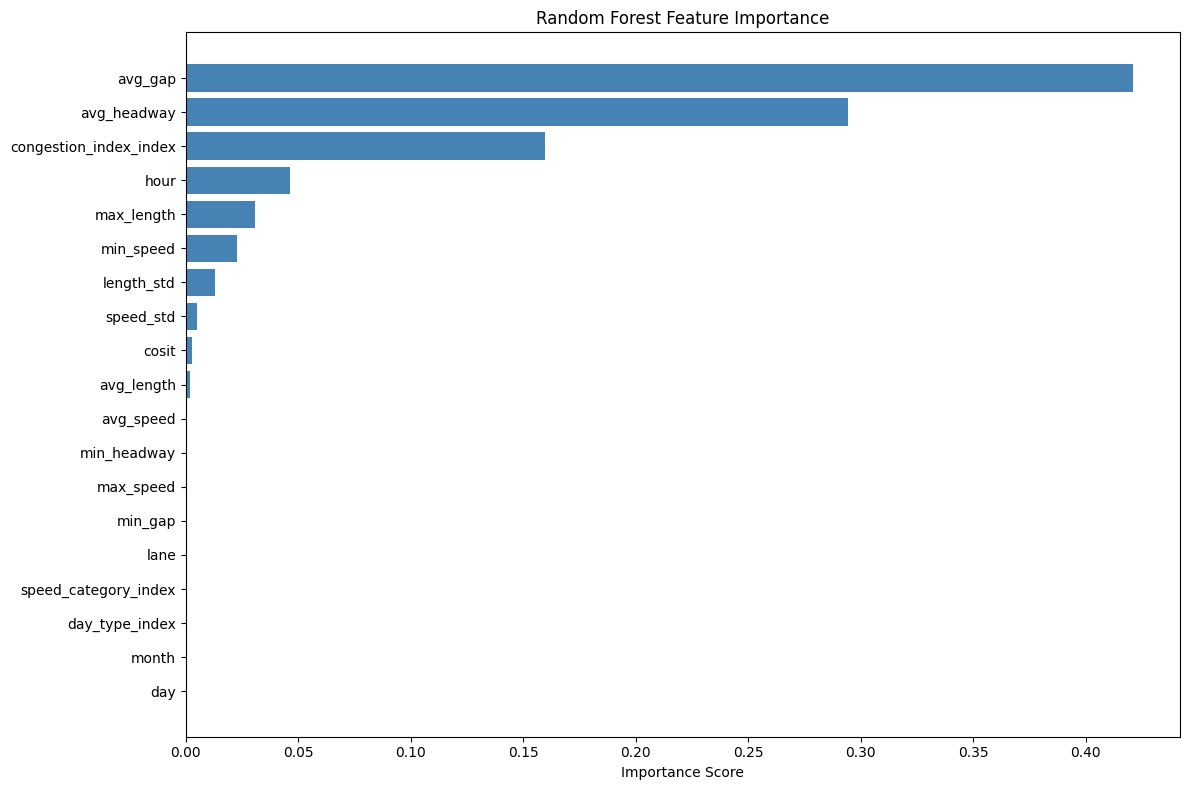

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.barh(
    importance_pdf["Feature"][::-1],
    importance_pdf["Importance"][::-1],
    color="steelblue",
    edgecolor="none"
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 5. Final Feature Selection

The final feature set is determined by combining insights from correlation analysis, multicollinearity checks, variance analysis, and model-based importance scores. Rather than relying solely on Random Forest importance scores, we incorporate domain knowledge to ensure the selected features tell a meaningful and complete story about Irish traffic behaviour.

### Features Excluded:
| Feature | Reason |
|---|---|
| `year` | Zero variance — entire dataset covers 2019 only |
| `traffic_level_index` | Direct leakage — binned from `vehicle_count` |
| `time_of_day_index` | Redundant — 0.97 correlation with `hour` |
| `max_headway`, `headway_std`, `max_gap`, `gap_std` | Multicollinearity — highly correlated with `avg_headway` and `avg_gap` |
| `CAR_count`, `LGV_count`, `HGV_ART_count` etc | Direct leakage — sum to `vehicle_count` |

### Features Retained:
While Random Forest importance scores highlight `avg_gap`, `avg_headway` and `congestion_index_index` as the strongest statistical predictors, temporal features such as `hour`, `day`, `month`, `day_type_index` and location features `cosit` and `lane` are retained based on domain knowledge. Traffic volume on Irish roads is inherently driven by time-of-day patterns, day of week, seasonal variation, and sensor location — excluding these features would produce a model that performs well statistically but lacks real-world interpretability and generalisability.

In [0]:
final_features = [
    # Sensor measurement features
    "avg_speed", "max_speed", "min_speed", "speed_std",
    "avg_length", "max_length", "length_std",
    "avg_headway", "min_headway",
    "avg_gap", "min_gap",
    # Temporal features
    "month", "day", "hour",
    # Location identifiers
    "cosit", "lane",
    # Encoded categorical features
    "day_type_index", "speed_category_index", "congestion_index_index"
]

target = "vehicle_count"

print("Final ML Feature Set:")
print("-" * 45)
for i, f in enumerate(final_features):
    print(f"  {i+1:>3}. {f}")
print("-" * 45)
print(f"Total features : {len(final_features)}")
print(f"Target         : {target}")

Final ML Feature Set:
---------------------------------------------
    1. avg_speed
    2. max_speed
    3. min_speed
    4. speed_std
    5. avg_length
    6. max_length
    7. length_std
    8. avg_headway
    9. min_headway
   10. avg_gap
   11. min_gap
   12. month
   13. day
   14. hour
   15. cosit
   16. lane
   17. day_type_index
   18. speed_category_index
   19. congestion_index_index
---------------------------------------------
Total features : 19
Target         : vehicle_count


### 5.1 Saving Final Feature Set

The final feature set is saved for use in the baseline model training notebook.

In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

assembler_a = VectorAssembler(inputCols=final_features, outputCol="features_a")
rf_a        = RandomForestRegressor(
                  featuresCol="features_a", labelCol="vehicle_count",
                  numTrees=50, maxDepth=8, seed=42
              )
pipeline_a  = Pipeline(stages=[assembler_a, rf_a])

assembler_b = VectorAssembler(inputCols=pre_available_features, outputCol="features_b")
rf_b        = RandomForestRegressor(
                  featuresCol="features_b", labelCol="vehicle_count",
                  numTrees=50, maxDepth=8, seed=42
              )
pipeline_b  = Pipeline(stages=[assembler_b, rf_b])

print("Training Model A (all features)...")
model_a = pipeline_a.fit(df)
print("Training Model B (pre-available features only)...")
model_b = pipeline_b.fit(df)
print("Both models trained.")

Training Model A (all features)...
Training Model B (pre-available features only)...
Both models trained.


Model                                           R² Score
---------------------------------------------------------
Model A — All features (benchmark)                0.9839
Model B — Pre-available features only (deployable)     0.5105

Model A shows the upper bound of predictive power.
Model B shows realistic deployable performance.
Gap = 47.34% — the cost of removing concurrent sensor features.


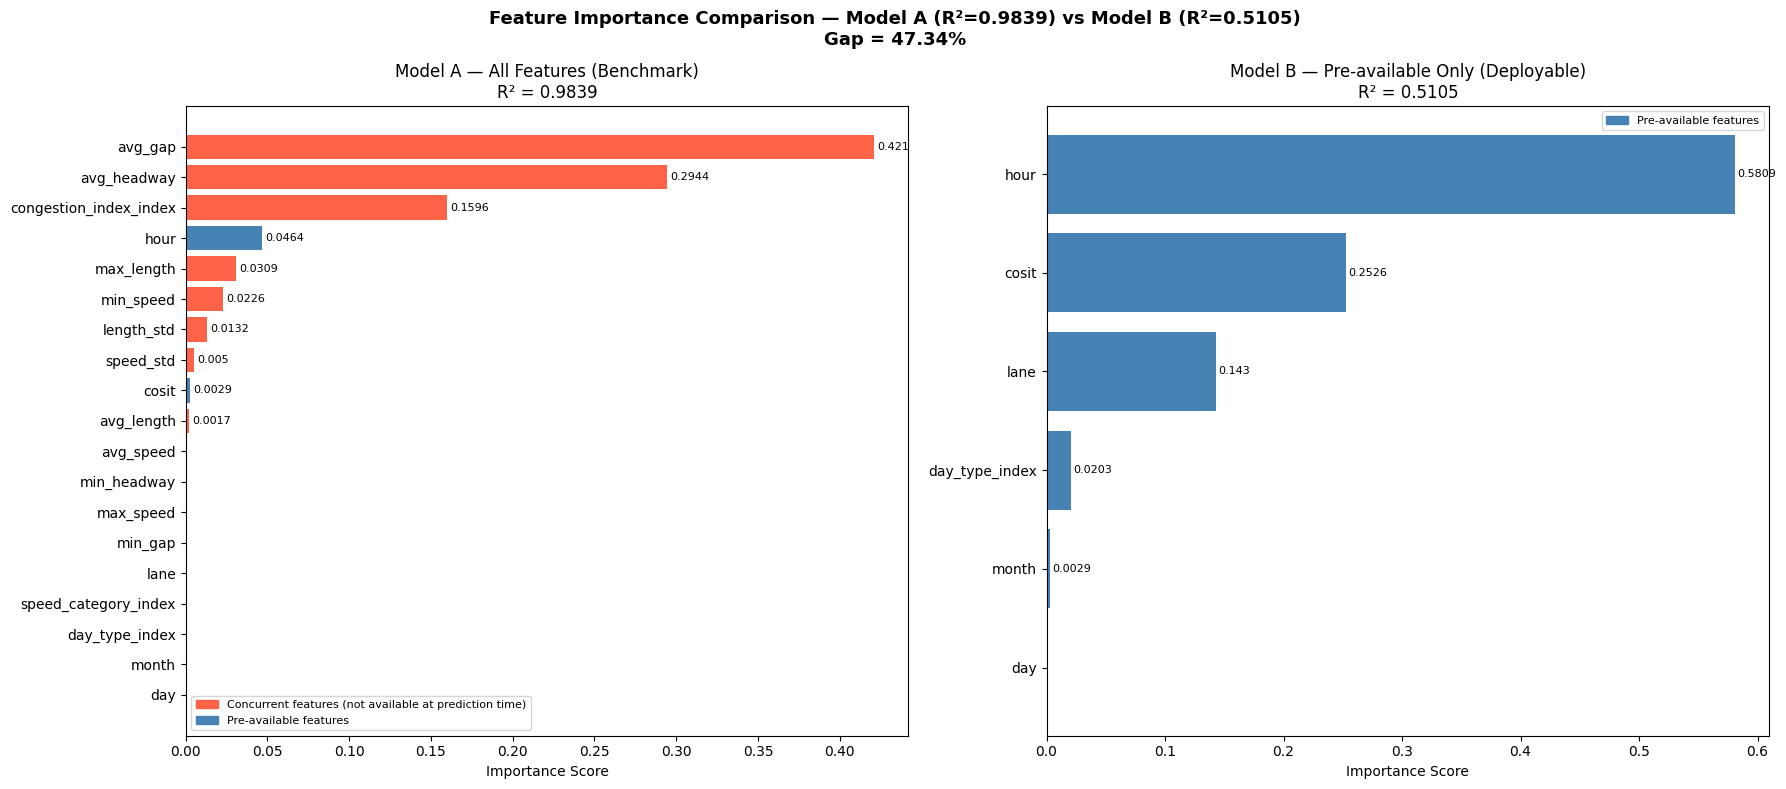

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

evaluator = RegressionEvaluator(
    labelCol="vehicle_count", predictionCol="prediction", metricName="r2"
)


preds_a = model_a.transform(df)
preds_b = model_b.transform(df)

r2_a = evaluator.evaluate(preds_a)
r2_b = evaluator.evaluate(preds_b)

print(f"{'Model':<45} {'R² Score':>10}")
print("-" * 57)
print(f"{'Model A — All features (benchmark)':<45} {round(r2_a, 4):>10}")
print(f"{'Model B — Pre-available features only (deployable)':<45} {round(r2_b, 4):>10}")
print()
print("Model A shows the upper bound of predictive power.")
print("Model B shows realistic deployable performance.")
print(f"Gap = {round((r2_a - r2_b) * 100, 2)}% — the cost of removing concurrent sensor features.")

importance_a = model_a.stages[-1].featureImportances.toArray()
importance_b = model_b.stages[-1].featureImportances.toArray()

importance_pdf_a = pd.DataFrame({
    "Feature"    : final_features,
    "Importance" : importance_a,
    "Model"      : "Model A — All Features (Benchmark)"
}).sort_values("Importance", ascending=True)

importance_pdf_b = pd.DataFrame({
    "Feature"    : pre_available_features,
    "Importance" : importance_b,
    "Model"      : "Model B — Pre-available Only (Deployable)"
}).sort_values("Importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

colors_a = [
    "tomato" if f in concurrent_features else "steelblue"
    for f in importance_pdf_a["Feature"]
]

axes[0].barh(
    importance_pdf_a["Feature"],
    importance_pdf_a["Importance"],
    color=colors_a, edgecolor="none"
)
axes[0].set_title(f"Model A — All Features (Benchmark)\nR² = {round(r2_a, 4)}", fontsize=12)
axes[0].set_xlabel("Importance Score")

for i, (val, feat) in enumerate(zip(importance_pdf_a["Importance"], importance_pdf_a["Feature"])):
    if val > 0.001:
        axes[0].text(val + 0.002, i, f"{round(val, 4)}", va="center", fontsize=8)

from matplotlib.patches import Patch
legend_a = [
    Patch(color="tomato",    label="Concurrent features (not available at prediction time)"),
    Patch(color="steelblue", label="Pre-available features")
]
axes[0].legend(handles=legend_a, fontsize=8)

axes[1].barh(
    importance_pdf_b["Feature"],
    importance_pdf_b["Importance"],
    color="steelblue", edgecolor="none"
)
axes[1].set_title(f"Model B — Pre-available Only (Deployable)\nR² = {round(r2_b, 4)}", fontsize=12)
axes[1].set_xlabel("Importance Score")

for i, (val, feat) in enumerate(zip(importance_pdf_b["Importance"], importance_pdf_b["Feature"])):
    if val > 0.001:
        axes[1].text(val + 0.002, i, f"{round(val, 4)}", va="center", fontsize=8)

legend_b = [
    Patch(color="steelblue", label="Pre-available features")
]
axes[1].legend(handles=legend_b, fontsize=8)

plt.suptitle(
    f"Feature Importance Comparison — Model A (R²={round(r2_a,4)}) vs Model B (R²={round(r2_b,4)})\nGap = {round((r2_a - r2_b)*100, 2)}%",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [0]:
df_final = df.select(final_features + [target])
df_final.write.mode("overwrite").saveAsTable("traffic_features_final")

print("Final feature dataset saved as : traffic_features_final")
print("Total rows                     :", f"{df_final.count():,}")
print("Total columns                  :", len(df_final.columns))

Final feature dataset saved as : traffic_features_final
Total rows                     : 7,503,913
Total columns                  : 20
